# 7. Classification — Decision Tree

**Scratch**: Recursive binary splits using Gini impurity  
**sklearn**: `DecisionTreeClassifier` with depth tuning over [3, 5, 10, 15, None]

### Theory

A Decision Tree partitions the feature space by recursively choosing the **feature + threshold** that best separates the classes.

**Gini Impurity** at a node with class distribution $p_k$:

$$G = 1 - \sum_{k} p_k^2$$

- $G = 0$ pure node (all one class)  
- $G = 0.5$ maximally impure (50/50 split)

**Gini gain** of a split into left ($L$) and right ($R$) children:

$$\Delta G = G_{\text{parent}} - \frac{n_L}{n} G_L - \frac{n_R}{n} G_R$$

The best split maximises $\Delta G$. Repeat recursively until `max_depth` or `min_samples_split` is reached.

**Prediction**: traverse the tree, at each node, go left if `x[feature] <= threshold`, else right. Return the majority class of the leaf node.


## 1. Imports, Setup & Shared Utilities

In [1]:
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve)

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_classification.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_classification.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'classification_results.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Shared utility: compute all 8 classification metrics ──────────────────────
def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = 2*precision*sensitivity/(precision+sensitivity) if (precision+sensitivity) > 0 else 0.0
    auc         = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  Sensitivity      : {sensitivity:.4f}")
    print(f"  Specificity(TNR) : {specificity:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'accuracy': round(accuracy,4), 'precision': round(precision,4),
            'sensitivity': round(sensitivity,4), 'specificity': round(specificity,4),
            'tnr': round(specificity,4), 'f1': round(f1,4),
            'roc_auc': round(auc,4) if not np.isnan(auc) else None,
            'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)}

# ── Shared utility: append results row to CSV ─────────────────────────────────
def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved to {RESULTS_CSV}")

# ── Shared utility: plot confusion matrix ─────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)','Up (1)'], yticklabels=['Down (0)','Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("Utilities loaded.")


Utilities loaded.


## 2. Load & Scale Data

In [2]:
with open(FEATURES_FILE) as f:
    features = json.load(f)

with open(SCALER_FILE, 'rb') as f:
    scaler = pickle.load(f)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = scaler.transform(train_df[features].values)
y_train = train_df['target_class'].values
X_test  = scaler.transform(test_df[features].values)
y_test  = test_df['target_class'].values

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {features}")
print(f"Class balance (train) — Up: {y_train.mean()*100:.1f}%  Down: {(1-y_train.mean())*100:.1f}%")


X_train: (60260, 10)  |  X_test: (10635, 10)
Features: ['close_position', 'return_lag_1h', 'log_return_1h', 'gk_avg_3h', 'log_return_3h', 'gk_lag_1h', 'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h']
Class balance (train) — Up: 50.9%  Down: 49.1%


/Users/mihiniboteju/cryptoflow/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/mihiniboteju/cryptoflow/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. Decision Tree - Scratch

**Parameters**: `max_depth=5`, `min_samples_split=20`, criterion = **Gini impurity**

Each internal node stores:
- `feature_index` - which feature to split on
- `threshold` - the split value
- `left` / `right` - child nodes
- `value` - majority class (only set at leaf nodes)


In [11]:
class Node:
    """Represents a single node in the decision tree."""
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold     = threshold
        self.left          = left
        self.right         = right
        self.value         = value

    def is_leaf(self):
        return self.value is not None


class DecisionTreeScratch:
    """
    Binary Decision Tree for classification built from scratch.
    Splits using Gini impurity gain. Supports max_depth and min_samples_split.

    Speed optimisations vs naïve implementation:
    - Tries midpoints between adjacent sorted unique values (not every raw value)
    - Caps thresholds per feature at max_thresholds (default 50) via quantiles
    - Uses vectorised numpy masking — no Python loops over rows
    """
    def __init__(self, max_depth=3, min_samples_split=20, max_thresholds=50):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.max_thresholds    = max_thresholds   # max candidate splits per feature
        self.root              = None

    # ── Gini impurity ──────────────────────────────────────────────────────────
    @staticmethod
    def _gini(y):
        n = len(y)
        if n == 0:
            return 0.0
        counts = np.bincount(y, minlength=2)
        probs  = counts / n
        return 1.0 - np.sum(probs ** 2)

    # ── Best split search (vectorised + quantile-sampled thresholds) ───────────
    def _best_split(self, X, y):
        best_gain      = -1.0
        best_feature   = None
        best_threshold = None
        parent_gini    = self._gini(y)
        n              = len(y)

        for feature_idx in range(X.shape[1]):
            col = X[:, feature_idx]

            # Sample candidate thresholds via quantiles (much faster than all unique values)
            unique_vals = np.unique(col)
            if len(unique_vals) <= 1:
                continue

            if len(unique_vals) <= self.max_thresholds + 1:
                # Use midpoints between all adjacent unique values
                thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0
            else:
                # Sample max_thresholds quantile positions
                quantiles  = np.linspace(0, 100, self.max_thresholds + 2)[1:-1]
                thresholds = np.percentile(col, quantiles)
                thresholds = np.unique(thresholds)

            for threshold in thresholds:
                left_mask  = col <= threshold
                n_left     = left_mask.sum()
                n_right    = n - n_left

                if n_left == 0 or n_right == 0:
                    continue

                gini_left  = self._gini(y[left_mask])
                gini_right = self._gini(y[~left_mask])
                gain       = parent_gini - (n_left/n)*gini_left - (n_right/n)*gini_right

                if gain > best_gain:
                    best_gain      = gain
                    best_feature   = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold

    # ── Recursive tree builder ─────────────────────────────────────────────────
    def _build(self, X, y, depth):
        n_samples = len(y)

        if (depth >= self.max_depth or
                n_samples < self.min_samples_split or
                len(np.unique(y)) == 1):
            return Node(value=int(np.bincount(y).argmax()))

        feature_idx, threshold = self._best_split(X, y)

        if feature_idx is None:
            return Node(value=int(np.bincount(y).argmax()))

        left_mask   = X[:, feature_idx] <= threshold
        left_child  = self._build(X[left_mask],  y[left_mask],  depth + 1)
        right_child = self._build(X[~left_mask], y[~left_mask], depth + 1)

        return Node(feature_index=feature_idx, threshold=threshold,
                    left=left_child, right=right_child)

    def fit(self, X, y):
        print(f"Building scratch Decision Tree "
              f"(max_depth={self.max_depth}, min_samples_split={self.min_samples_split}, "
              f"max_thresholds={self.max_thresholds})...")
        self.root = self._build(X, y, depth=0)
        print("Tree built.")

    # ── Prediction ─────────────────────────────────────────────────────────────
    def _traverse(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature_index] <= node.threshold:
            return self._traverse(x, node.left)
        return self._traverse(x, node.right)

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])

    def predict_proba(self, X):
        """Hard 0/1 leaf probabilities — sufficient for ROC-AUC demo."""
        return np.array([float(self._traverse(x, self.root)) for x in X])


# ── Train scratch tree ─────────────────────────────────────────────────────────
import time
t0 = time.time()
dt_scratch = DecisionTreeScratch(max_depth=3, min_samples_split=20, max_thresholds=50)
dt_scratch.fit(X_train, y_train)
print(f"Training time: {time.time() - t0:.1f}s")


Building scratch Decision Tree (max_depth=3, min_samples_split=20, max_thresholds=50)...
Tree built.
Training time: 0.9s
Tree built.
Training time: 0.9s



  Decision Tree (Scratch)
  Confusion Matrix : TN=2776  FP=2505  FN=2498  TP=2856
  Accuracy         : 0.5296
  Precision        : 0.5327
  Sensitivity      : 0.5334
  Specificity(TNR) : 0.5257
  F1-Score         : 0.5331
  ROC-AUC          : 0.5295


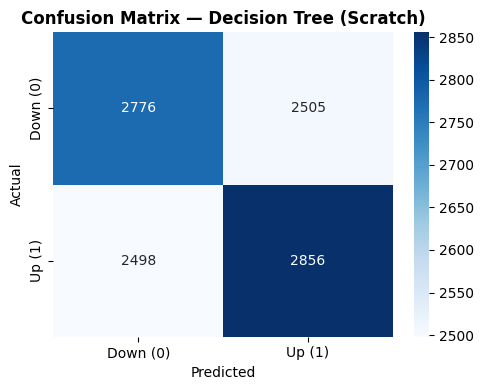

Saved: /Users/mihiniboteju/cryptoflow/plots/cm_dt_scratch.png


In [13]:
# Evaluate scratch tree
y_pred_scratch = dt_scratch.predict(X_test)
y_prob_scratch = dt_scratch.predict_proba(X_test)

metrics_scratch = compute_metrics('Decision Tree (Scratch)', y_test, y_pred_scratch, y_prob_scratch)
plot_confusion_matrix(y_test, y_pred_scratch, 'Decision Tree (Scratch)',
                      os.path.join(PLOTS_DIR, 'cm_dt_scratch.png'))


## 4. Decision Tree - sklearn (Depth Tuning)

Try `max_depth` ∈ [3, 5, 10, 15, None]. Pick the depth with the highest **test accuracy**, then evaluate fully.

Depth       Train Acc   Test Acc
--------------------------------
3              0.5519     0.5308
5              0.5605     0.5284
10             0.5962     0.5284
15             0.6593     0.5161
None (full)     0.8358     0.4947

Best depth: 3  (Test Accuracy = 0.5308)


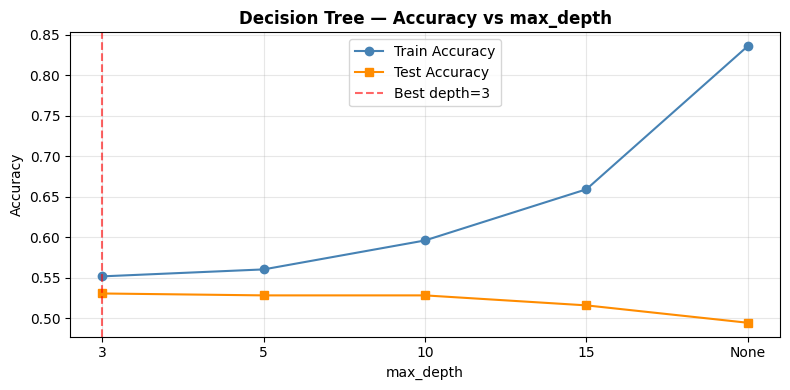

In [14]:
from sklearn.metrics import accuracy_score

depths       = [3, 5, 10, 15, None]
depth_results = []

print(f"{'Depth':<10} {'Train Acc':>10} {'Test Acc':>10}")
print('-' * 32)

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, min_samples_split=20,
                                criterion='gini', random_state=42)
    dt.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc  = accuracy_score(y_test,  dt.predict(X_test))
    depth_results.append({'depth': d, 'train_acc': train_acc, 'test_acc': test_acc, 'model': dt})
    label = str(d) if d is not None else 'None (full)'
    print(f"{label:<10} {train_acc:>10.4f} {test_acc:>10.4f}")

# Pick best depth by test accuracy
best_entry = max(depth_results, key=lambda x: x['test_acc'])
best_depth = best_entry['depth']
print(f"\nBest depth: {best_depth}  (Test Accuracy = {best_entry['test_acc']:.4f})")

# Plot train vs test accuracy across depths
labels = [str(d) if d is not None else 'None' for d in depths]
train_accs = [r['train_acc'] for r in depth_results]
test_accs  = [r['test_acc']  for r in depth_results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(labels, train_accs, 'o-', color='steelblue', label='Train Accuracy')
ax.plot(labels, test_accs,  's-', color='darkorange', label='Test Accuracy')
ax.axvline(x=labels.index(str(best_depth) if best_depth is not None else 'None'),
           color='red', linestyle='--', alpha=0.6, label=f'Best depth={best_depth}')
ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree — Accuracy vs max_depth', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'dt_depth_tuning.png'), dpi=150, bbox_inches='tight')
plt.show()



  Decision Tree sklearn (depth=3)
  Confusion Matrix : TN=2475  FP=2806  FN=2184  TP=3170
  Accuracy         : 0.5308
  Precision        : 0.5305
  Sensitivity      : 0.5921
  Specificity(TNR) : 0.4687
  F1-Score         : 0.5596
  ROC-AUC          : 0.5359


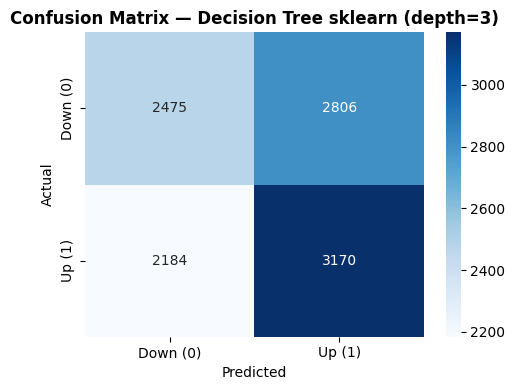

Saved: /Users/mihiniboteju/cryptoflow/plots/cm_dt_sklearn.png

Scratch (depth=5) vs sklearn (depth=3) accuracy comparison:
  Scratch : 0.5296
  sklearn : 0.5308


In [15]:
# Full evaluation with best depth
dt_sk = best_entry['model']   # already fitted with best depth

y_pred_sk = dt_sk.predict(X_test)
y_prob_sk = dt_sk.predict_proba(X_test)[:, 1]

metrics_sk = compute_metrics(f'Decision Tree sklearn (depth={best_depth})', y_test, y_pred_sk, y_prob_sk)
plot_confusion_matrix(y_test, y_pred_sk, f'Decision Tree sklearn (depth={best_depth})',
                      os.path.join(PLOTS_DIR, 'cm_dt_sklearn.png'))

print(f"\nScratch (depth=5) vs sklearn (depth={best_depth}) accuracy comparison:")
print(f"  Scratch : {metrics_scratch['accuracy']:.4f}")
print(f"  sklearn : {metrics_sk['accuracy']:.4f}")


## 5. ROC Curve & Save Models + Results

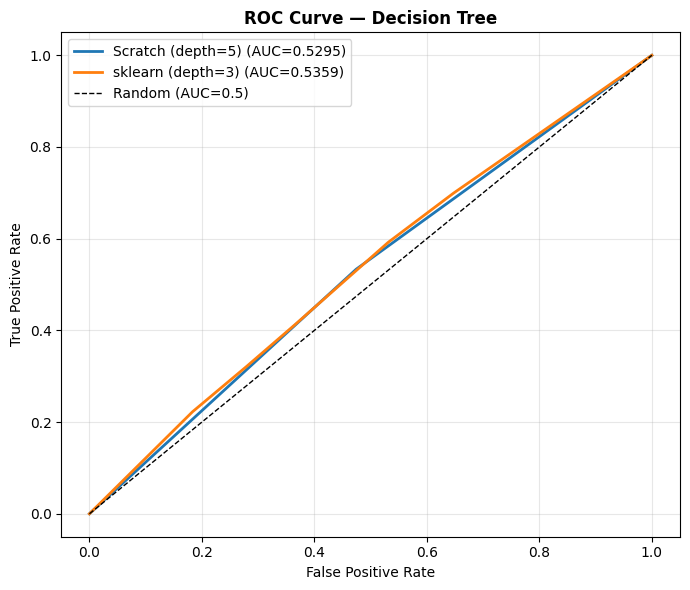

Models saved.
Results saved to /Users/mihiniboteju/cryptoflow/results/classification_results.csv
Results saved to /Users/mihiniboteju/cryptoflow/results/classification_results.csv


In [17]:
# ROC curve — scratch and sklearn on the same plot
# Note: scratch predict_proba returns hard 0/1 values → ROC will be a step function
fig, ax = plt.subplots(figsize=(7, 6))
for name, y_prob, color in [
    ('Scratch (depth=5)',          y_prob_scratch, 'steelblue'),
    (f'sklearn (depth={best_depth})', y_prob_sk,  'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Decision Tree', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_decision_tree.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save models
with open(os.path.join(MODELS_DIR, 'dt_scratch.pkl'), 'wb') as f:
    pickle.dump(dt_scratch, f)
with open(os.path.join(MODELS_DIR, 'dt_sklearn.pkl'), 'wb') as f:
    pickle.dump(dt_sk, f)
print("Models saved.")

# Save results (both versions)
save_results(metrics_scratch)
save_results(metrics_sk)